In [0]:

# Loading and Storing the data
from pyspark.sql.functions import col, to_date, to_timestamp

# Loading the data
df = spark.table("indian_banking_transactions")

print("Data Loaded Successfully!")


Data Loaded Successfully!


In [0]:
# checking dimension of dataset and column names
print("Total rows:", df.count())
print("Total columns:", len(df.columns))
print("\nColumn names:", df.columns)


Total rows: 550000
Total columns: 20

Column names: ['transaction_id', 'customer_id', 'transaction_date', 'transaction_time', 'account_type', 'transaction_type', 'transaction_amount', 'transaction_direction', 'account_balance', 'merchant_category', 'state', 'credit_score', 'has_loan', 'loan_type', 'emi_amount', 'transaction_status', 'channel', 'kyc_status', 'is_fraud', 'transaction_hour']


In [0]:
df.show(5)


+--------------+-----------+----------------+-------------------+-------------+----------------+------------------+---------------------+---------------+-----------------+-----------+------------+--------+---------+----------+------------------+----------+----------+--------+----------------+
|transaction_id|customer_id|transaction_date|   transaction_time| account_type|transaction_type|transaction_amount|transaction_direction|account_balance|merchant_category|      state|credit_score|has_loan|loan_type|emi_amount|transaction_status|   channel|kyc_status|is_fraud|transaction_hour|
+--------------+-----------+----------------+-------------------+-------------+----------------+------------------+---------------------+---------------+-----------------+-----------+------------+--------+---------+----------+------------------+----------+----------+--------+----------------+
|  TXN000000001| CUST015796|      2019-01-01|2026-06-01 15:28:00|      Current|             UPI|           1820.17|   

In [0]:
df.printSchema()

root
 |-- transaction_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- transaction_date: date (nullable = true)
 |-- transaction_time: timestamp (nullable = true)
 |-- account_type: string (nullable = true)
 |-- transaction_type: string (nullable = true)
 |-- transaction_amount: double (nullable = true)
 |-- transaction_direction: string (nullable = true)
 |-- account_balance: double (nullable = true)
 |-- merchant_category: string (nullable = true)
 |-- state: string (nullable = true)
 |-- credit_score: long (nullable = true)
 |-- has_loan: long (nullable = true)
 |-- loan_type: string (nullable = true)
 |-- emi_amount: double (nullable = true)
 |-- transaction_status: string (nullable = true)
 |-- channel: string (nullable = true)
 |-- kyc_status: string (nullable = true)
 |-- is_fraud: long (nullable = true)
 |-- transaction_hour: long (nullable = true)



In [0]:
# Cleaning and Saving data to Delta Lake (ETL)
from pyspark.sql.functions import col, to_date

# Correcting data types
df_clean = df \
    .withColumn("transaction_date", to_date(col("transaction_date"), "yyyy-MM-dd")) \
    .withColumn("transaction_amount", col("transaction_amount").cast("float")) \
    .withColumn("account_balance", col("account_balance").cast("float")) \
    .withColumn("credit_score", col("credit_score").cast("integer")) \
    .withColumn("is_fraud", col("is_fraud").cast("integer")) \
    .withColumn("emi_amount", col("emi_amount").cast("float")) \
    .withColumn("transaction_hour", col("transaction_hour").cast("integer")) \

df_clean.printSchema()


root
 |-- transaction_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- transaction_date: date (nullable = true)
 |-- transaction_time: timestamp (nullable = true)
 |-- account_type: string (nullable = true)
 |-- transaction_type: string (nullable = true)
 |-- transaction_amount: float (nullable = true)
 |-- transaction_direction: string (nullable = true)
 |-- account_balance: float (nullable = true)
 |-- merchant_category: string (nullable = true)
 |-- state: string (nullable = true)
 |-- credit_score: integer (nullable = true)
 |-- has_loan: long (nullable = true)
 |-- loan_type: string (nullable = true)
 |-- emi_amount: float (nullable = true)
 |-- transaction_status: string (nullable = true)
 |-- channel: string (nullable = true)
 |-- kyc_status: string (nullable = true)
 |-- is_fraud: integer (nullable = true)
 |-- transaction_hour: integer (nullable = true)



In [0]:
df_clean = df \
    .dropna(subset=["transaction_amount", "is_fraud"])

print("Data Cleaned!")
print("Total clean rows:", df_clean.count())

Data Cleaned!
Total clean rows: 550000


In [0]:
df_clean = df \
    .dropDuplicates(["transaction_id"])

print("Removing duplicate values")
print("Total after removing duplicates:", df_clean.count())

Removing duplicate values
Total after removing duplicates: 550000


In [0]:
spark.sql("DROP TABLE IF EXISTS banking_delta")
# Saving data to Delta Lake
df_clean.write.format("delta") \
    .mode("overwrite") \
    .option("mergeSchema", "true").saveAsTable("banking_delta")

print("Saved to Delta Lake as 'banking_delta'!")

Saved to Delta Lake as 'banking_delta'!


In [0]:
spark.catalog.tableExists("banking_delta")

True

In [0]:
spark.table("banking_deltaa").show(10, truncate=False)

+--------------+-----------+----------------+-------------------+------------+----------------+------------------+---------------------+---------------+-----------------+-----------+------------+--------+---------+----------+------------------+------------+----------+--------+----------------+
|transaction_id|customer_id|transaction_date|transaction_time   |account_type|transaction_type|transaction_amount|transaction_direction|account_balance|merchant_category|state      |credit_score|has_loan|loan_type|emi_amount|transaction_status|channel     |kyc_status|is_fraud|transaction_hour|
+--------------+-----------+----------------+-------------------+------------+----------------+------------------+---------------------+---------------+-----------------+-----------+------------+--------+---------+----------+------------------+------------+----------+--------+----------------+
|TXN000000009  |CUST016024 |2019-01-01      |2026-06-01 20:25:00|Salary      |Credit_Card     |3284.62           |D

In [0]:
# MapReduce on Banking Transactions
from pyspark.sql.functions import count, avg, sum, max, min, round, col

# Loading data from Delta Lake
df = spark.table("banking_delta")

# Total transactions and fraud counting by State
print("=== MAP-REDUCE 1: Fraud Analysis by State ===")
fraud_by_state = df.groupBy("state") \
    .agg(
        count("transaction_id").alias("total_transactions"),
        sum("is_fraud").alias("fraud_count"),
        round(avg("is_fraud") * 100, 2).alias("fraud_percentage")
    ).orderBy("fraud_count", ascending=False)
fraud_by_state.show(10)


=== MAP-REDUCE 1: Fraud Analysis by State ===
+-----------+------------------+-----------+----------------+
|      state|total_transactions|fraud_count|fraud_percentage|
+-----------+------------------+-----------+----------------+
|Maharashtra|             98911|        885|            0.89|
|  Karnataka|             76659|        701|            0.91|
| Tamil Nadu|             71747|        633|            0.88|
|      Delhi|             66114|        588|            0.89|
|    Gujarat|             54798|        482|            0.88|
|  Telangana|             49610|        440|            0.89|
|West Bengal|             43950|        413|            0.94|
|  Rajasthan|             38725|        303|            0.78|
|         UP|             27414|        260|            0.95|
|     Punjab|             22072|        168|            0.76|
+-----------+------------------+-----------+----------------+



In [0]:
# Transaction volume by channel
print("=== MAP-REDUCE 2: Transactions by Channel ===")
by_channel = df.groupBy("channel") \
    .agg(
        count("transaction_id").alias("total_transactions"),
        round(avg("transaction_amount"), 2).alias("avg_amount"),
        sum("is_fraud").alias("fraud_count")
    ).orderBy("total_transactions", ascending=False)
by_channel.show()

=== MAP-REDUCE 2: Transactions by Channel ===
+------------+------------------+----------+-----------+
|     channel|total_transactions|avg_amount|fraud_count|
+------------+------------------+----------+-----------+
|  Mobile_App|            208368|  29966.36|       1809|
|         Web|            121010|   30261.6|       1080|
|         ATM|             66177|  29624.41|        561|
|POS_Terminal|             60853|  29698.19|        557|
|      Branch|             54957|  29224.44|        520|
|         API|             38635|  30261.39|        346|
+------------+------------------+----------+-----------+



In [0]:
# Monthly trend (Time Series)
from pyspark.sql.functions import month, year

print("=== MAP-REDUCE 3: Monthly Transaction Trend ===")
monthly = df.groupBy(
        year("transaction_date").alias("year"),
        month("transaction_date").alias("month")
    ) \
    .agg(
        count("transaction_id").alias("total_transactions"),
        round(sum("transaction_amount"), 2).alias("total_amount"),
        sum("is_fraud").alias("fraud_count")
    ).orderBy("year", "month")
monthly.show(24)

=== MAP-REDUCE 3: Monthly Transaction Trend ===
+----+-----+------------------+--------------+-----------+
|year|month|total_transactions|  total_amount|fraud_count|
+----+-----+------------------+--------------+-----------+
|2019|    1|              9406|2.4953589179E8|         73|
|2019|    2|              8220|2.4317358854E8|         76|
|2019|    3|              9290|2.6062864743E8|         86|
|2019|    4|              8990|2.7364641165E8|        100|
|2019|    5|              9425|2.7437266632E8|         87|
|2019|    6|              9107|2.6597430192E8|         78|
|2019|    7|              9400|2.9593478383E8|         84|
|2019|    8|              9524|3.1657489938E8|         72|
|2019|    9|              8877|2.6168669397E8|         66|
|2019|   10|              9576|2.6875122427E8|         87|
|2019|   11|              8922|2.6766506425E8|         73|
|2019|   12|              9346|2.8052105914E8|         86|
|2020|    1|              9440|2.6742280548E8|         84|
|2020|  

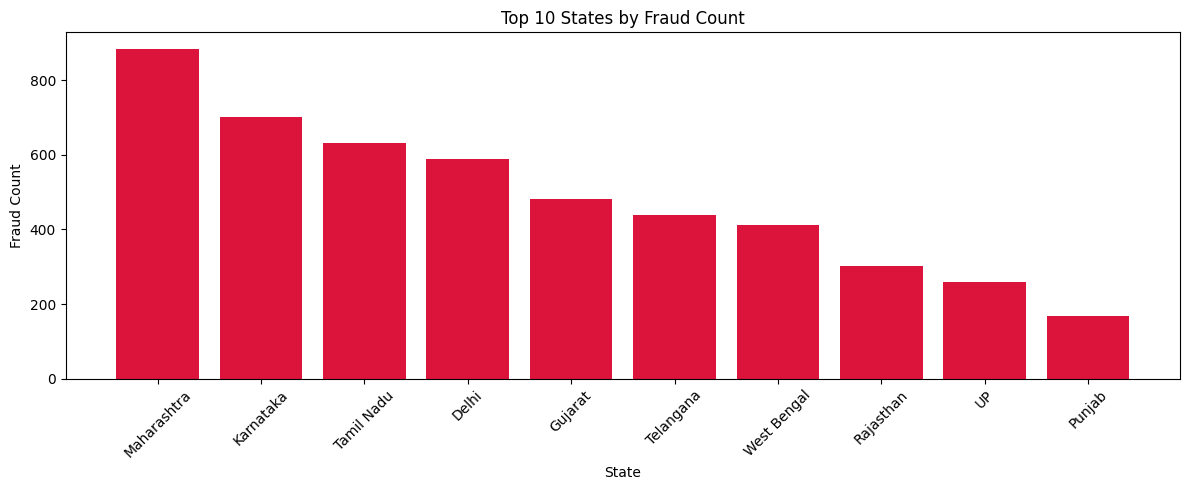

In [0]:
# Visualising the results
import matplotlib.pyplot as plt

# Fraud by State (top 10)
pdf_state = fraud_by_state.limit(10).toPandas()
plt.figure(figsize=(12, 5))
plt.bar(pdf_state['state'], pdf_state['fraud_count'], color='crimson')
plt.title('Top 10 States by Fraud Count')
plt.xlabel('State')
plt.ylabel('Fraud Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


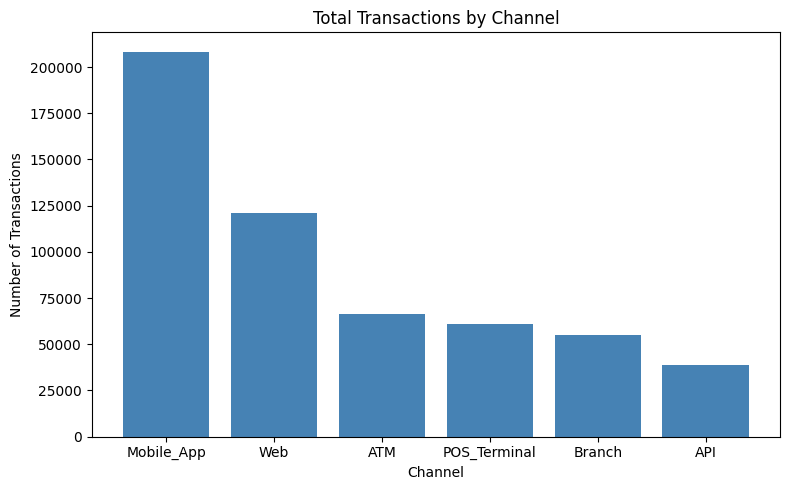

In [0]:
# Transactions by Channel
pdf_channel = by_channel.toPandas()
plt.figure(figsize=(8, 5))
plt.bar(pdf_channel['channel'], pdf_channel['total_transactions'], color='steelblue')
plt.title('Total Transactions by Channel')
plt.xlabel('Channel')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

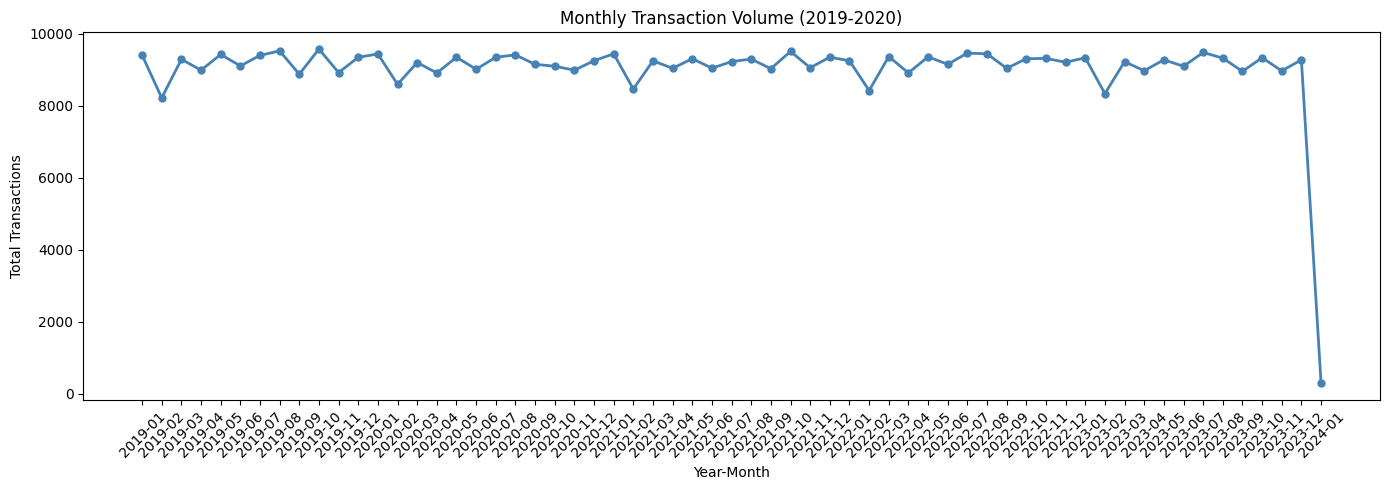

In [0]:
# Monthly Transaction Trend - Time Series Chart
import matplotlib.pyplot as plt

# Converting monthly results to Pandas
pdf_monthly = monthly.toPandas()

# Create a combined year-month label like "2019-01", "2019-02" etc.
pdf_monthly['year_month'] = pdf_monthly['year'].astype(str) + '-' + pdf_monthly['month'].astype(str).str.zfill(2)

# Monthly Total Transactions
plt.figure(figsize=(14, 5))
plt.plot(pdf_monthly['year_month'], pdf_monthly['total_transactions'], 
         marker='o', color='steelblue', linewidth=2, markersize=5)
plt.title('Monthly Transaction Volume (2019-2020)')
plt.xlabel('Year-Month')
plt.ylabel('Total Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



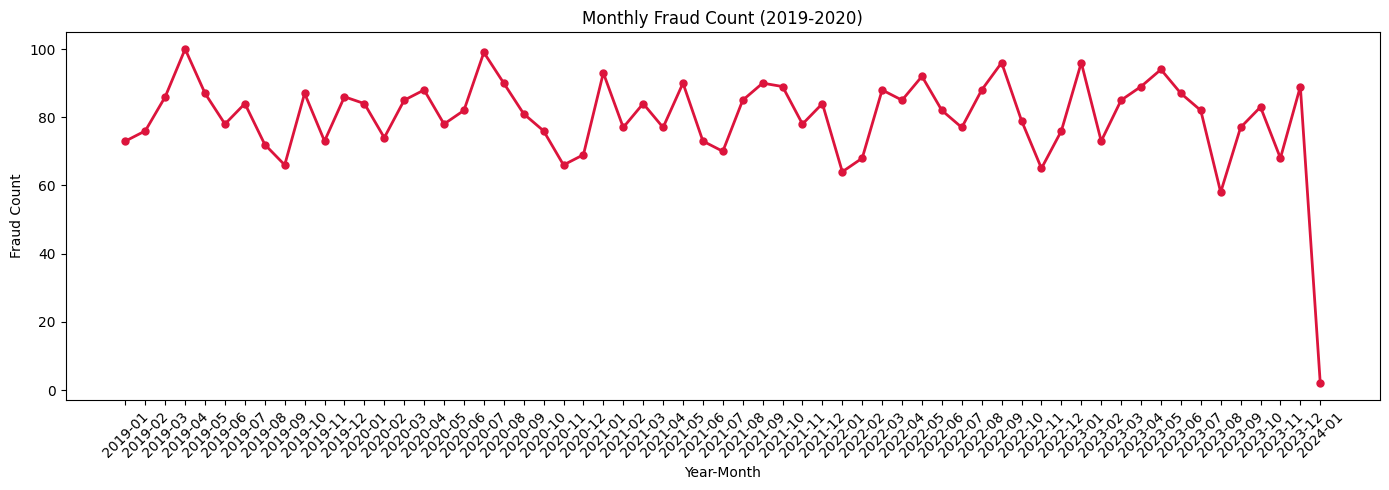

In [0]:
# Monthly Fraud Count
plt.figure(figsize=(14, 5))
plt.plot(pdf_monthly['year_month'], pdf_monthly['fraud_count'], 
         marker='o', color='crimson', linewidth=2, markersize=5)
plt.title('Monthly Fraud Count (2019-2020)')
plt.xlabel('Year-Month')
plt.ylabel('Fraud Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [0]:
# Data Preparation
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.sql.functions import col, month, year, hour

# Loading data from Delta Lake
df = spark.table("banking_delta")

# Add time features from transaction_date
df = df.withColumn("month_num", month(col("transaction_date"))) \
       .withColumn("year_num", year(col("transaction_date")))

# Index categorical columns
indexer_channel = StringIndexer(inputCol="channel", outputCol="channel_idx", handleInvalid="keep")
indexer_type = StringIndexer(inputCol="transaction_type", outputCol="type_idx", handleInvalid="keep")
indexer_account = StringIndexer(inputCol="account_type", outputCol="account_idx", handleInvalid="keep")

df = indexer_channel.fit(df).transform(df)
df = indexer_type.fit(df).transform(df)
df = indexer_account.fit(df).transform(df)

# Select feature columns
feature_cols = ["transaction_amount", "account_balance", "credit_score",
                "transaction_hour", "month_num", "year_num",
                "channel_idx", "type_idx", "account_idx",
                "has_loan", "emi_amount"]

# Assemble features into one vector
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="keep")
df_ml = assembler.transform(df).select("features", "is_fraud", "transaction_amount")

# Split into train and test
train, test = df_ml.randomSplit([0.8, 0.2], seed=42)

print("Data Preparation Complete!")
print("Training rows:", train.count())
print("Testing rows:", test.count())
print("Features used:", feature_cols)

Data Preparation Complete!
Training rows: 439942
Testing rows: 110058
Features used: ['transaction_amount', 'account_balance', 'credit_score', 'transaction_hour', 'month_num', 'year_num', 'channel_idx', 'type_idx', 'account_idx', 'has_loan', 'emi_amount']


In [0]:
# Classification for Predict Fraud (is_fraud)
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# Training Random Forest model
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="is_fraud",
    numTrees=50,
    maxDepth=5,
    seed=42
)
rf_model = rf.fit(train)

# Making predictions
rf_predictions = rf_model.transform(test)

# Evaluation
accuracy_eval = MulticlassClassificationEvaluator(labelCol="is_fraud", metricName="accuracy")
f1_eval = MulticlassClassificationEvaluator(labelCol="is_fraud", metricName="f1")
auc_eval = BinaryClassificationEvaluator(labelCol="is_fraud", metricName="areaUnderROC")

accuracy = accuracy_eval.evaluate(rf_predictions)
f1 = f1_eval.evaluate(rf_predictions)
auc = auc_eval.evaluate(rf_predictions)

print("=== CLASSIFICATION RESULTS (Random Forest) ===")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")

# Showing sample predictions
print("\nSample Predictions:")
rf_predictions.select("is_fraud", "prediction", "probability").show(10)

=== CLASSIFICATION RESULTS (Random Forest) ===
Accuracy:  0.9911 (99.11%)
F1 Score:  0.9866
AUC-ROC:   0.5391

Sample Predictions:
+--------+----------+--------------------+
|is_fraud|prediction|         probability|
+--------+----------+--------------------+
|       0|       0.0|[0.99119460711929...|
|       0|       0.0|[0.99119460711929...|
|       0|       0.0|[0.99118060390530...|
|       0|       0.0|[0.99112671426748...|
|       0|       0.0|[0.99124475385939...|
|       0|       0.0|[0.99112398866197...|
|       0|       0.0|[0.99119460711929...|
|       0|       0.0|[0.99124475385939...|
|       0|       0.0|[0.99106295611806...|
|       0|       0.0|[0.99119460711929...|
+--------+----------+--------------------+
only showing top 10 rows


In [0]:
# Predicting Transaction Amount
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Training Linear Regression model
lr = LinearRegression(
    featuresCol="features",
    labelCol="transaction_amount",
    maxIter=10,
    regParam=0.3,
    elasticNetParam=0.8
)
lr_model = lr.fit(train)

# Make predictions
lr_predictions = lr_model.transform(test)

# Evaluation
rmse_eval = RegressionEvaluator(labelCol="transaction_amount", metricName="rmse")
r2_eval = RegressionEvaluator(labelCol="transaction_amount", metricName="r2")
mae_eval = RegressionEvaluator(labelCol="transaction_amount", metricName="mae")

rmse = rmse_eval.evaluate(lr_predictions)
r2 = r2_eval.evaluate(lr_predictions)
mae = mae_eval.evaluate(lr_predictions)

print("=== PREDICTION RESULTS (Linear Regression) ===")
print(f"RMSE:  {rmse:.2f}")
print(f"R2:    {r2:.4f}")
print(f"MAE:   {mae:.2f}")

print("\nSample Predictions vs Actual:")
lr_predictions.select("transaction_amount", "prediction").show(10)

=== PREDICTION RESULTS (Linear Regression) ===
RMSE:  0.29
R2:    1.0000
MAE:   0.10

Sample Predictions vs Actual:
+------------------+------------------+
|transaction_amount|        prediction|
+------------------+------------------+
|             34.81|34.874795551421904|
|             42.61| 42.67477795111482|
|             46.91| 46.97476790603754|
|             62.21|  62.2747341159523|
|              74.8| 74.86471090598796|
|             79.68| 79.74469762526287|
|             88.71| 88.77467691206948|
|             99.52|  99.5846511358016|
|            108.48|108.54463850826598|
|            109.36|109.42463386208924|
+------------------+------------------+
only showing top 10 rows


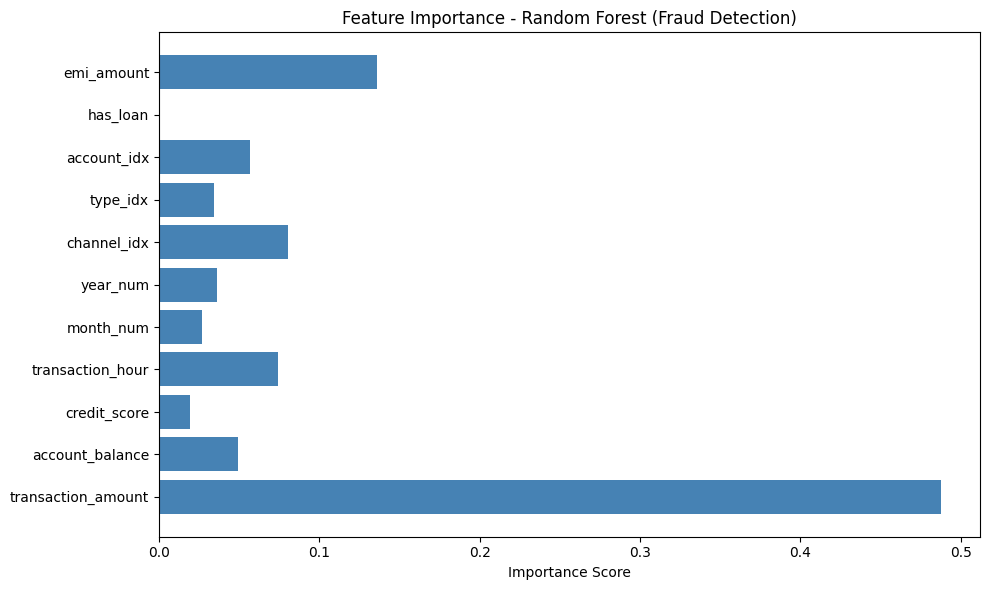

In [0]:
# Visualizing ML Results
import matplotlib.pyplot as plt
import numpy as np

# Feature Importance from Random Forest
importances = rf_model.featureImportances
feature_names = feature_cols
importance_values = [importances[i] for i in range(len(feature_names))]

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importance_values, color='steelblue')
plt.title('Feature Importance - Random Forest (Fraud Detection)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()



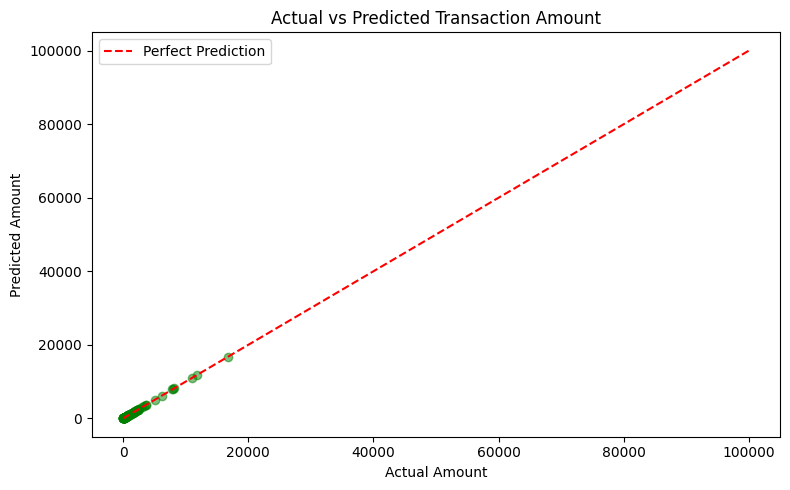

In [0]:
# Actual vs Predicted Transaction Amount (sample)
pdf_lr = lr_predictions.select("transaction_amount", "prediction").limit(100).toPandas()
plt.figure(figsize=(8, 5))
plt.scatter(pdf_lr['transaction_amount'], pdf_lr['prediction'], alpha=0.5, color='green')
plt.plot([0, 100000], [0, 100000], 'r--', label='Perfect Prediction')
plt.title('Actual vs Predicted Transaction Amount')
plt.xlabel('Actual Amount')
plt.ylabel('Predicted Amount')
plt.legend()
plt.tight_layout()
plt.show()